# Bt / Ip comparison: SELEC2007 (2008) and SELEC2024 (tc26)

Loads `Bt` and `Ip` for time-slices marked selected by `SELEC2007` (2008 dataset) and `SELEC2024` (tc26 dataset).

Both flags are stored in the SimDB manifest as `dbvariable.SELEC2007` / `dbvariable.SELEC2024` metadata.

Pulses are found and filtered by a SimDB metadata query first, so we only open the HDF5 `summary` IDS for pulses where the selection flag is true for at least one time-slice. 

`Database.query_meta` compares array-valued metadata with `np.any(value == compare)` for the default `EQ`
modifier, so `dbvariable.SELEC2007=1` matches any simulation whose SELEC array contains a 1.

In [9]:
import numpy as np
import imas

from simdb.config.config import Config
from simdb.database import get_local_db
from simdb.query import QueryType

config = Config()
db = get_local_db(config)

def query_selected_pulses(dataset: str, selec_key: str):
    """Return Simulations for `dataset` with at least one time-slice where dbvariable.<selec_key> == 1. """
    constraints = [
        ("dataset", dataset, QueryType.EQ),
        (f"dbvariable.{selec_key}", "1", QueryType.EQ),
    ]
    return db.query_meta(constraints)


sims_2008 = query_selected_pulses("2008", "SELEC2007")
sims_tc26 = query_selected_pulses("tc26", "SELEC2024")

print(f"2008 pulses with a SELEC2007-selected slice: {len(sims_2008)}")
print(f"tc26 pulses with a SELEC2024-selected slice: {len(sims_tc26)}")

2008 pulses with a SELEC2007-selected slice: 713
tc26 pulses with a SELEC2024-selected slice: 383


For each matched simulation: read the full SELEC array back out of metadata (still no IDS access) to build a boolean mask, resolve the `summary` IDS URI from `outputs`, then open and mask `Bt`/`Ip` to the selected slices.

In [20]:
def _dbentry_uri(file_uri) -> str:
    """Manifest output URIs are simdb.uri.URI objects carrying a #<ids-name> fragment; 
    rebuild the URI string expected by DBEntry from its `path` query value"""
    path = file_uri.query.get("path")
    return f"imas:hdf5?path={path};pulse=0"


def load_selected_bt_ip(sims, selec_key: str):
    """Return concatenated (Bt, Ip, machine) arrays over every selected slice across all given simulations."""
    bt_all, ip_all, machine_all = [], [], []
    n = len(sims)
    for i, sim in enumerate(sims, start=1):
        if i % 20 == 0 or i == n:
            print(f"\r  {i}/{n} pulses ({sim.alias})".ljust(80), end="", flush=True)

        selec = np.asarray(sim.meta_dict()["dbvariable"][selec_key])
        mask = selec == 1

        uri = _dbentry_uri(sim.outputs[0].uri)
        with imas.DBEntry(uri, "r") as entry:
            s = entry.get("summary", lazy=True)
            bt = np.asarray(s.global_quantities.b0.value, dtype=float)
            ip = np.asarray(s.global_quantities.ip.value, dtype=float)

        n_slices = min(len(mask), len(bt), len(ip))  
        selected = mask[:n_slices]
        machine = sim.meta_dict().get("machine", "")
        bt_all.append(bt[:n_slices][selected])
        ip_all.append(ip[:n_slices][selected])
        machine_all.append(np.full(selected.sum(), machine, dtype=object))
    print()

    if not bt_all:
        return np.array([]), np.array([]), np.array([], dtype=object)
    return np.concatenate(bt_all), np.concatenate(ip_all), np.concatenate(machine_all)


print("2008 / SELEC2007:")
bt_2008, ip_2008, machine_2008 = load_selected_bt_ip(sims_2008, "SELEC2007")
print("tc26 / SELEC2024:")
bt_tc26, ip_tc26, machine_tc26 = load_selected_bt_ip(sims_tc26, "SELEC2024")

print(f"2008 selected slices: {len(bt_2008)}")
print(f"tc26 selected slices: {len(bt_tc26)}")

2008 / SELEC2007:
  713/713 pulses (JT60U/33677)                                                 
tc26 / SELEC2024:
  383/383 pulses (JET/90528)                                                   
2008 selected slices: 1024
tc26 selected slices: 482


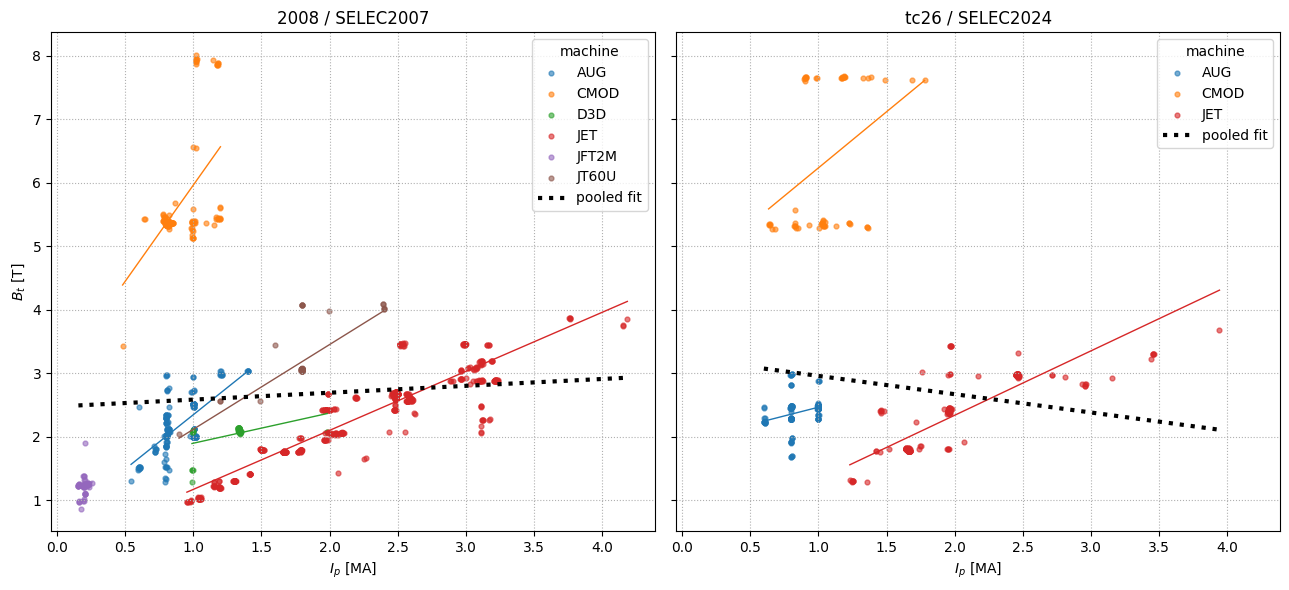

In [13]:
import matplotlib.pyplot as plt

machines = sorted(set(machine_2008) | set(machine_tc26))
colors = dict(zip(machines, plt.cm.tab10.colors))

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, title, bt, ip, machine in [
    (axes[0], "2008 / SELEC2007", bt_2008, ip_2008, machine_2008),
    (axes[1], "tc26 / SELEC2024", bt_tc26, ip_tc26, machine_tc26),
]:
    ip_ma = np.abs(ip) / 1e6
    bt_t = np.abs(bt)
    for m in machines:
        sel = machine == m
        if not sel.any():
            continue
        ax.scatter(ip_ma[sel], bt_t[sel], s=12, alpha=0.6, color=colors[m], label=m)
        if sel.sum() >= 2:
            coeffs = np.polyfit(ip_ma[sel], bt_t[sel], 1)
            x_fit = np.linspace(ip_ma[sel].min(), ip_ma[sel].max(), 20)
            ax.plot(x_fit, np.polyval(coeffs, x_fit), color=colors[m], linewidth=1)

    # pooled fit -- ignores machine identity, fit through every point in this panel
    pooled_coeffs = np.polyfit(ip_ma, bt_t, 1)
    x_pooled = np.linspace(ip_ma.min(), ip_ma.max(), 20)
    ax.plot(
        x_pooled, np.polyval(pooled_coeffs, x_pooled),
        color="black", linewidth=3, linestyle=":", label="pooled fit",
    )

    ax.set_title(title)
    ax.set_xlabel("$I_p$ [MA]")
    ax.grid(True, linestyle=":")
    ax.legend(title="machine")

axes[0].set_ylabel("$B_t$ [T]")
fig.tight_layout()

Whether a scaling law that regresses on both `Ip` and `Bt` can actually tell their effects apart depends on `r_within`, the Pearson correlation between `Ip` and `Bt` inside a given machine.

In [14]:
def report_correlations(label, bt, ip, machine):
    ip_ma = np.abs(ip) / 1e6
    bt_t = np.abs(bt)

    print(label)
    for m in sorted(set(machine)):
        sel = machine == m
        if sel.sum() < 2:
            continue
        r = np.corrcoef(ip_ma[sel], bt_t[sel])[0, 1]
        print(f"  {m:8s} r_within = {r:+.2f}  (n={sel.sum()})")

    pooled_r = np.corrcoef(ip_ma, bt_t)[0, 1]
    print(f"  {'pooled':8s} r        = {pooled_r:+.2f}  (n={len(bt)})")
    print()


report_correlations("2008 / SELEC2007", bt_2008, ip_2008, machine_2008)
report_correlations("tc26 / SELEC2024", bt_tc26, ip_tc26, machine_tc26)

2008 / SELEC2007
  AUG      r_within = +0.67  (n=175)
  CMOD     r_within = +0.51  (n=115)
  D3D      r_within = +0.48  (n=56)
  JET      r_within = +0.92  (n=562)
  JFT2M    r_within = +0.20  (n=58)
  JT60U    r_within = +0.76  (n=58)
  pooled   r        = +0.07  (n=1024)

tc26 / SELEC2024
  AUG      r_within = +0.29  (n=162)
  CMOD     r_within = +0.37  (n=59)
  JET      r_within = +0.83  (n=261)
  pooled   r        = -0.13  (n=482)

